# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/credit_risk_dataset.csv', sep=None, engine='python')

df.shape

(32581, 12)

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
target_dist = df['loan_status'].value_counts()
target_percent = df['loan_status'].value_counts(normalize=True) * 100

target_percent

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

Більшість клієнтів не мають дефолту (приблизно 78%), а дефолти складають лише ~22%. Тому датасет є незбалансованим. Це важливо, бо модель може гірше передбачати саме дефолти.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [6]:
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent[missing_percent > 0]

person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [9]:
df.select_dtypes(include=['int64', 'float64']).describe().round(3)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000,32581.000,32581.000,32581.000,32581.000,32581.000,32581.000,32581.000
mean,27.735,66074.848,4.768,9589.371,11.010,0.218,0.170,5.804
std,6.348,61983.119,4.087,6322.087,3.082,0.413,0.107,4.055
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,8.490,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12200.000,13.110,0.000,0.230,8.000
max,144.000,6000000.000,123.000,35000.000,23.220,1.000,0.830,30.000


In [10]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]

print(f"Кількість викидів: {len(outliers)}")
print(f"Нижня межа: {lower_bound:.2f}")
print(f"Верхня межа: {upper_bound:.2f}")

Кількість викидів: 1484
Нижня межа: -22550.00
Верхня межа: 140250.00


In [11]:
df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)].copy()

print(f"До: {df.shape[0]}, {df.shape[1]}")
print(f"Після: {df_clean.shape[0]}, {df_clean.shape[1]}")

До: 32581, 12
Після: 31097, 12


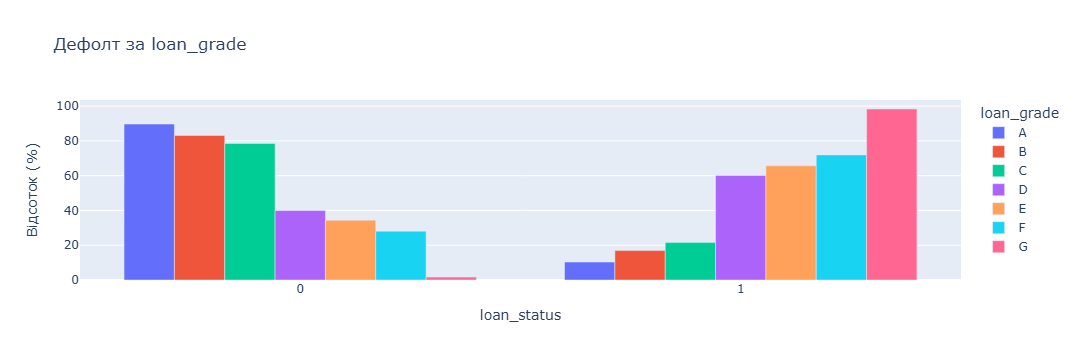

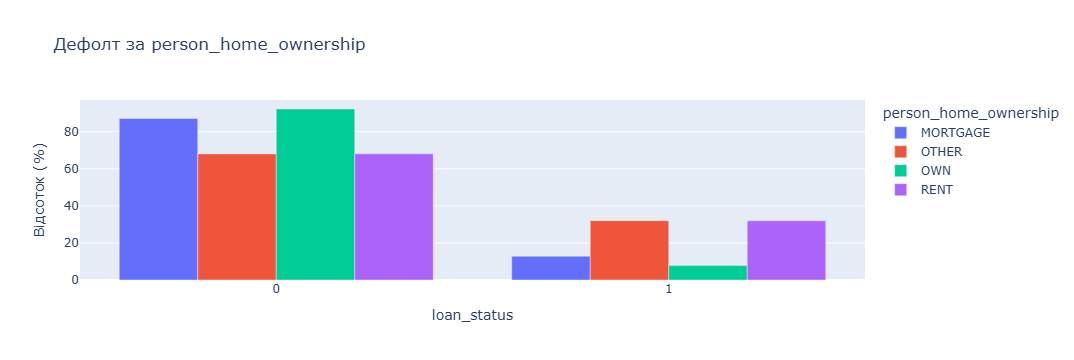

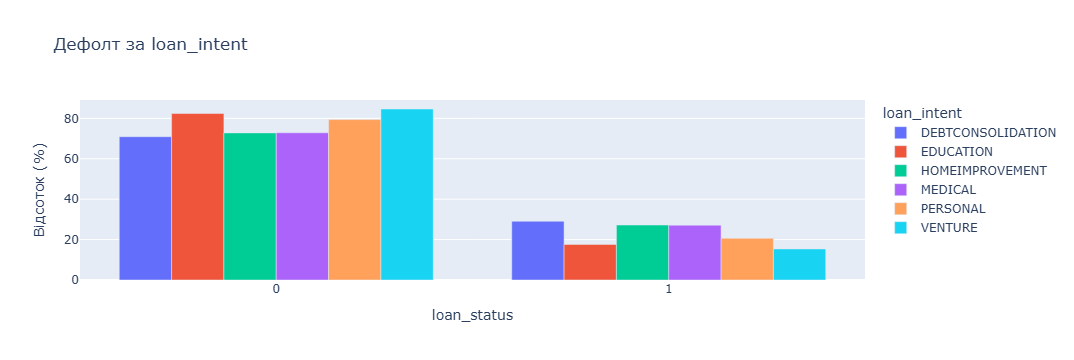

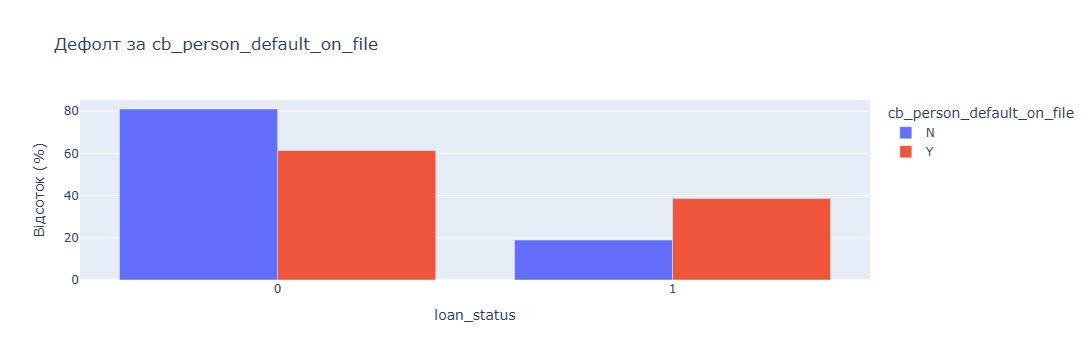

In [12]:
cat_cols = [
    'loan_grade',
    'person_home_ownership',
    'loan_intent',
    'cb_person_default_on_file'
]

for col in cat_cols:
    temp = df_clean.groupby([col, 'loan_status']).size().unstack()
    temp_pct = temp.div(temp.sum(axis=1), axis=0) * 100
    
    fig = px.bar(
        temp_pct.T,
        title=f'Дефолт за {col}',
        labels={'value': 'Відсоток (%)', 'index': 'Статус кредиту'},
        barmode='group'
    )
    
    fig.show()

Аналіз категоріальних змінних показав, що найбільший вплив на ймовірність дефолту мають кредитний рейтинг (loan_grade) та історія дефолтів (cb_person_default_on_file). Також важливими є мета кредиту та тип житла. Деякі категорії мають значно вищий рівень дефолтів, що свідчить про їхню важливість для побудови моделі прогнозування кредитного ризику.

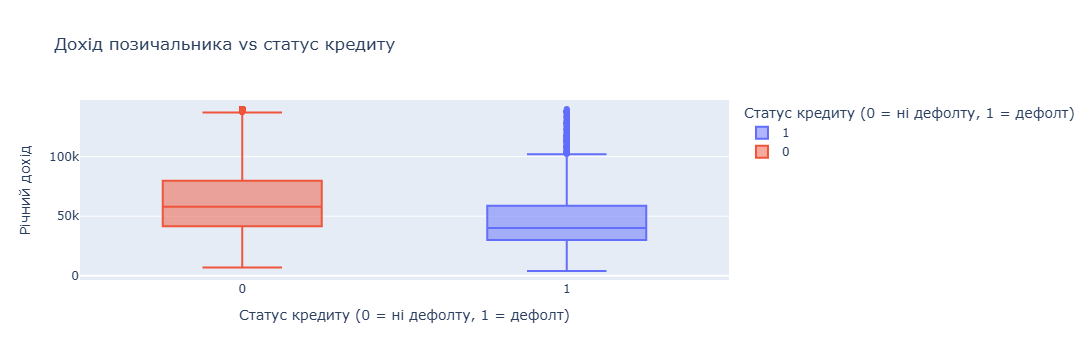

In [13]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='person_income',
    title='Дохід позичальника vs статус кредиту',
    labels={
        'person_income': 'Річний дохід',
        'loan_status': 'Статус кредиту (0 = ні дефолту, 1 = дефолт)'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Позичальники з дефолтом зазвичай мають нижчий дохід, ніж ті, хто успішно повертає кредит.

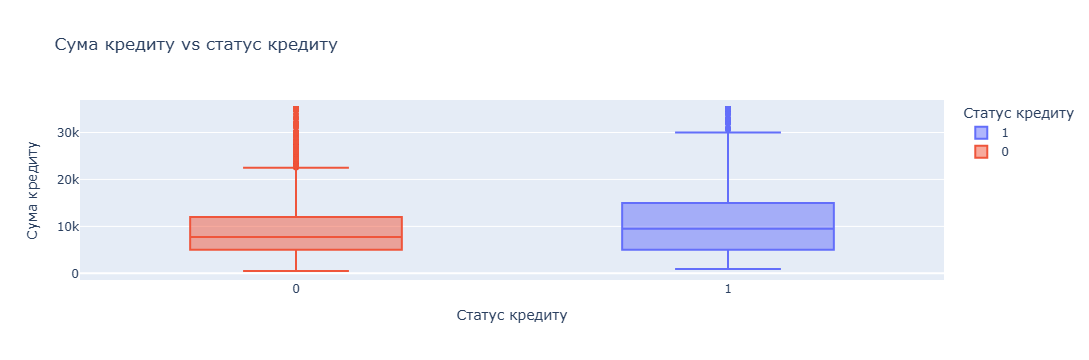

In [14]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_amnt',
    title='Сума кредиту vs статус кредиту',
    labels={
        'loan_amnt': 'Сума кредиту',
        'loan_status': 'Статус кредиту'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Клієнти з дефолтом, як правило, беруть більші суми кредиту, ніж клієнти без дефолту.

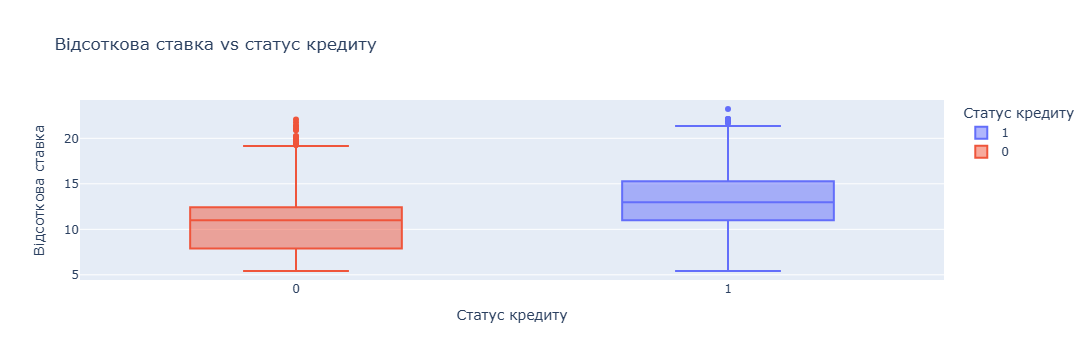

In [15]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_int_rate',
    title='Відсоткова ставка vs статус кредиту',
    labels={
        'loan_int_rate': 'Відсоткова ставка',
        'loan_status': 'Статус кредиту'
    },
    color='loan_status'
)

fig.show()

**Висновок:** Позичальники з дефолтом мають вищі відсоткові ставки, що може свідчити про більший кредитний ризик.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [16]:
num_cols = df_clean.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_cols.corr()

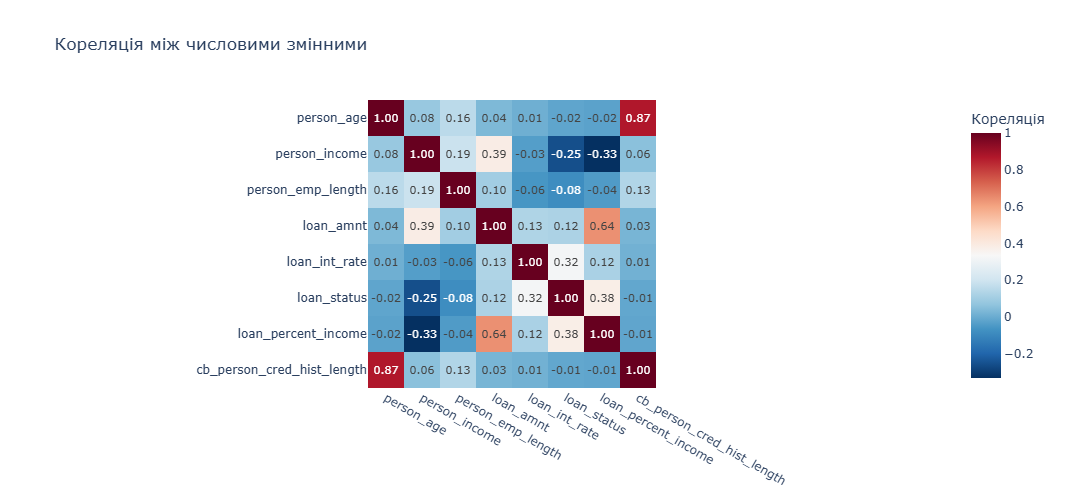

In [17]:
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими змінними',
    labels=dict(color="Кореляція")
)

fig.update_layout(height=500)
fig.show()

Найбільше на дефолт впливають loan_percent_income та loan_int_rate - чим вони більші, тим вищий ризик. Дохід (person_income) має зворотний зв’язок: чим більший дохід, тим менше дефолтів. Також є сильна кореляція між person_age і cb_person_cred_hist_length, тому ці ознаки частково дублюють одна одну.

In [18]:
df_model = df_clean.drop(columns=['person_age'])

In [19]:
all_cat_cols = df_model.select_dtypes('object').columns.tolist()

In [20]:
selected_cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

df_encoded = pd.get_dummies(
    df_model,
    columns=selected_cat_cols,
    drop_first=True
)

In [21]:
df_encoded.head()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [22]:
exclude_cols = ['loan_status'] + all_cat_cols

feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [23]:
X = df_encoded[feature_cols]
y = df_encoded['loan_status']

In [24]:
X.head()

,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,59000,123.0,35000,16.02,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,9600,5.0,1000,11.14,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,9600,1.0,5500,12.87,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,65500,4.0,35000,15.23,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,54400,8.0,35000,14.27,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} позичальників")
print(f"Test: {X_test.shape[0]} позичальників")
print(f"Частка дефолтів у train: {y_train.mean():.1%}")
print(f"Частка дефолтів у test: {y_test.mean():.1%}")

Train: 24877 позичальників
Test: 6220 позичальників
Частка дефолтів у train: 22.4%
Частка дефолтів у test: 22.4%


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [28]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [29]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_train_pred_proba = model.predict_proba(X_train_scaled)
y_test_pred_proba = model.predict_proba(X_test_scaled)

In [30]:
y_test_pred_custom = (y_test_pred_proba[:, 1] > 0.6).astype(int)

In [31]:
sample_predictions = pd.DataFrame({
    'Реальний статус': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'Ймовірн. повернення': y_test_pred_proba[:5, 0].round(3),
    'Ймовірн. дефолту': y_test_pred_proba[:5, 1].round(3)
})

print(sample_predictions)

   Реальний статус  Прогноз  Ймовірн. повернення  Ймовірн. дефолту
0                0        0                0.969             0.031
1                0        0                0.986             0.014
2                0        0                0.965             0.035
3                0        0                0.966             0.034
4                0        1                0.171             0.829



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


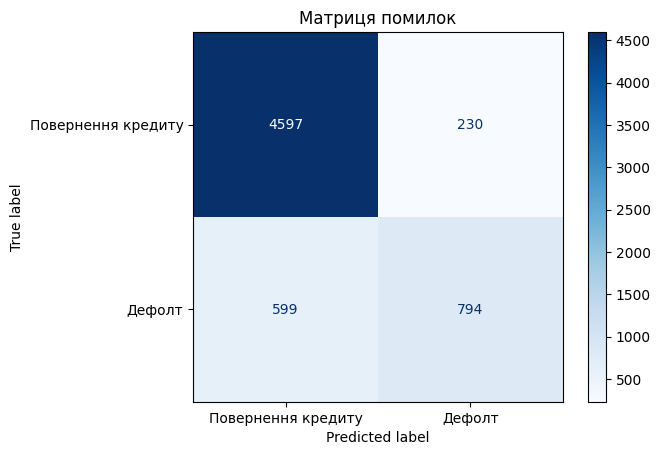

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Повернення кредиту', 'Дефолт']
)

disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (загальна точність): {accuracy:.3f}")
print(f"Precision (точність дефолтів): {precision:.3f}")
print(f"Recall (повнота дефолтів): {recall:.3f}")
print(f"F1-score: {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (загальна точність): 0.867
Precision (точність дефолтів): 0.775
Recall (повнота дефолтів): 0.570
F1-score: 0.657


In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_test_pred_proba[:, 1])

print(f"AUC: {auc:.3f}")

AUC: 0.875


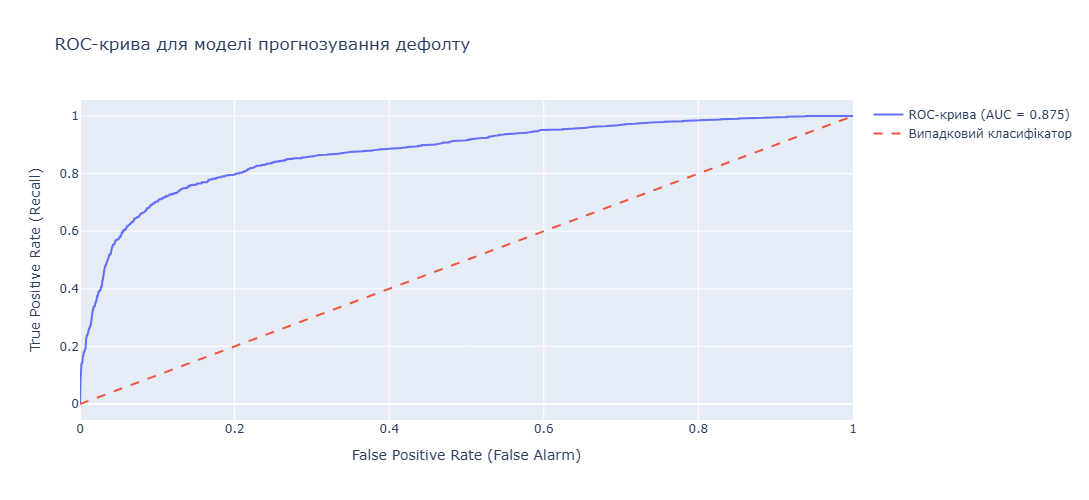

In [35]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC-крива (AUC = {auc:.3f})'
))

fig.add_trace(go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    line=dict(dash='dash'),
    name='Випадковий класифікатор'
))

fig.update_layout(
    title='ROC-крива для моделі прогнозування дефолту',
    xaxis_title='False Positive Rate (False Alarm)',
    yaxis_title='True Positive Rate (Recall)',
    height=500
)

fig.show()

In [36]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values(by='abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
4,loan_percent_income,1.313651,1.313651
16,loan_grade_D,0.818449,0.818449
2,loan_amnt,-0.541304,0.541304
17,loan_grade_E,0.480786,0.480786
7,person_home_ownership_OWN,-0.456138,0.456138
8,person_home_ownership_RENT,0.404903,0.404903
13,loan_intent_VENTURE,-0.399919,0.399919
9,loan_intent_EDUCATION,-0.325639,0.325639
19,loan_grade_G,0.313225,0.313225
18,loan_grade_F,0.271244,0.271244


Модель працює досить добре: вона правильно визначає більшість клієнтів (accuracy ~ 87%, AUC ~ 0.88). Але є складність - вона пропускає частину дефолтів (recall ~ 57%), тобто не завжди знаходить ризикових клієнтів. При цьому, якщо модель вже передбачила дефолт, то в більшості випадків це правда (precision ~ 78%). Загалом модель хороша, але її потрібно покращити, щоб краще знаходити дефолти.

Найбільше на ризик дефолту впливають:


- loan_percent_income (якщо кредит займає велику частину доходу, ризик вищий)
- loan_grade (чим гірший рейтинг, тим більший ризик)
- loan_amnt (великі кредити частіше пов’язані з ризиком)
- person_home_ownership (тип житла теж має вплив)
- loan_intent (тобто, мета кредиту - деякі типи кредитів ризикованіші)


Також вплив мають:


- person_income (більший дохід - менший ризик)
- loan_int_rate (більша відсоткова ставка - більший ризик)

Майже не впливають:


- cb_person_cred_hist_length
- cb_person_default_on_file


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



    threshold  precision    recall        f1
0        0.10   0.391415  0.883704  0.542530
1        0.15   0.471219  0.852118  0.606851
2        0.20   0.530700  0.800431  0.638237
3        0.25   0.582609  0.769562  0.663161
4        0.30   0.627223  0.734386  0.676587
5        0.35   0.676389  0.699210  0.687610
6        0.40   0.710078  0.657574  0.682818
7        0.45   0.741602  0.618090  0.674236
8        0.50   0.775391  0.569993  0.657013
9        0.55   0.791077  0.521895  0.628893
10       0.60   0.810878  0.470926  0.595822
11       0.65   0.807365  0.409189  0.543116
12       0.70   0.833613  0.356066  0.498994
13       0.75   0.850410  0.297918  0.441255
14       0.80   0.873057  0.241924  0.378865
15       0.85   0.906475  0.180905  0.301616


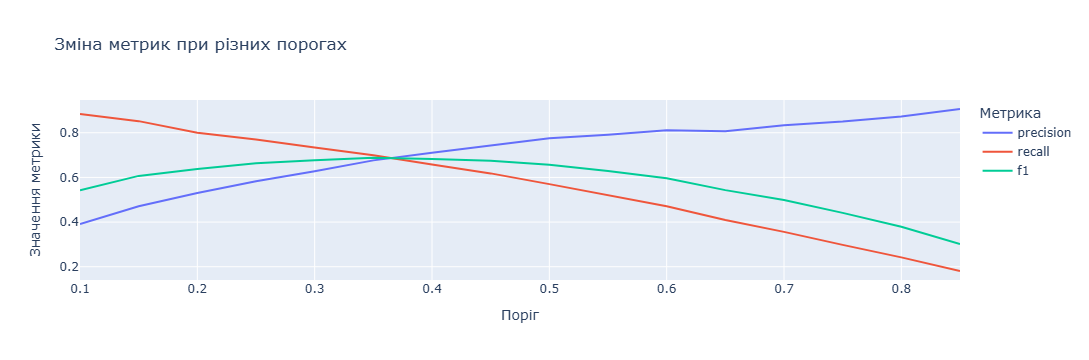

In [37]:
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_test_pred_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

print(metrics_df)

fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Зміна метрик при різних порогах',
    labels={
        'value': 'Значення метрики',
        'threshold': 'Поріг',
        'variable': 'Метрика'
    }
)

fig.show()

Оптимальний поріг який оптимізує точність - 0.45. При такому порозі модель краще виявляє дефолти, ніж при стандартному порозі 0.5, зберігаючи прийнятний баланс між precision та recall.

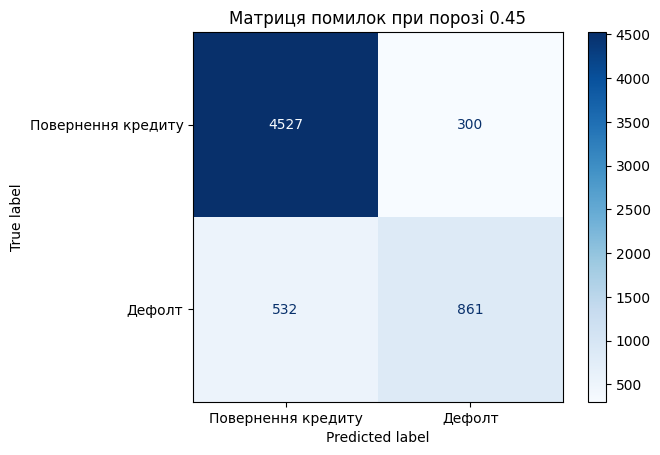

In [38]:
y_pred_opt = (y_test_pred_proba[:, 1]>=0.45).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Повернення кредиту', 'Дефолт']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Матриця помилок при порозі 0.45')
plt.show()


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)

results_df

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.867,0.775,0.570,0.657,0.875
1,Decision Tree,0.903,0.954,0.594,0.732,0.872
2,Random Forest,0.927,0.952,0.709,0.813,0.926


Для порівняння моделей було використано стандартний поріг 0.5, щоб оцінити їхню базову якість. 

Найкращий результат показала модель Random Forest, оскільки вона має найвищі значення F1-score та AUC, а також краще за інші моделі знаходить дефолти (вищий recall).